In [588]:
# Partially Pooled 10/29/24

'''
I'm attempting to re-create the partially pooled model from the R package and paper. 

I've noticed a few differences that will make an exact re-creation difficult.

Optimizer: R package uses OSQP, I'm using scipy.optimize.minimize
Residuals: R packages uses A-SCM so fits extra model to the residuals. We can do this, but not with staggered adoption. 

Creating a new notebook, that will take the spirit of the partially pooled model, but will not be an exact re-creation and I'll be using linear regression. 
'''

In [648]:
#pip install osqp

In [590]:
import osqp

In [6]:
import sys 
sys.path.insert(0, '..')

In [649]:
from __future__ import annotations
import numpy as np
import pandas as pd
import scipy.stats as st
from dataclasses import dataclass
import warnings
from matplotlib import pyplot as plt
from scipy.optimize import minimize
from panel_exp import panel_data
import seaborn as sns

sns.set_style("darkgrid")



from panel_exp.methods.synthetic_control import synthetic_control, ridge_augsynth 

In [8]:
data = pd.read_csv('/Users/christopherb/downloads/Paglayan.csv' )


In [473]:
data = data[(~data['State'].isin(['DC', 'WI'])) & (data['year']>=1959) & (data['year']<=1997)] 

In [474]:
wide_df = pd.pivot_table(data, columns='year', index='State', values='lnppexpend')
units=wide_df.index
periods=wide_df.columns

In [475]:
#wide_df

In [521]:
demean = True

if demean:
    # de-mean
    wide_df = pd.DataFrame(wide_df.values - wide_df.mean(axis=1).values.reshape(-1,1))
    wide_df.index = units
    wide_df.columns = periods

treated = pd.pivot_table(data, columns='year', index='State', values='cbr')

In [522]:
treated.head()

year,1959,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997
State,,,,,,,,,,,,,,,,,,,,,
AK,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
AL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AR,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AZ,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [523]:
treated_times = [panel_data.TimePeriod(start=treated.columns[treated.loc[s]==1][0], end=treated.columns[treated.loc[s]==1][-1]) for s in treated.index if len(treated.columns[treated.loc[s]==1])>0]

treated_units = [s for s in treated.index if len(treated.columns[treated.loc[s]==1])>0]
control_units = [s for s in wide_df.index if s not in treated_units]     

In [562]:
penalty_strength = 0.00
penalty = "l2"

In [563]:
y = wide_df.loc[treated_units]
X = wide_df.loc[[unit for unit in wide_df.index if unit not in treated_units]]

In [564]:
def treated_mask():
    '''
    returns matrix of wide_df shape with zeros and one's where one's indicate treatment
    '''
    mask = []

    for u in range(len(treated_times)):
        trt = []
        for x in wide_df.columns:
            trt.append(1 if x >= treated_times[u].start and x<= treated_times[u].end else 0)
        mask.append(trt)

    mask = np.array(mask)
    
    return mask 

In [565]:
mask = treated_mask()

In [566]:
mask.shape

(32, 39)

In [567]:
print((treated.loc[treated_units].values == mask).shape)
print((treated.loc[treated_units].values == mask).sum())
print(32*39)

(32, 39)
1248
1248


In [568]:
def sep_balance_objective(x): 
    x = x.reshape((17,32))
    state_imbalance = (test.T.values - np.dot(control, x)) * np.abs(mask-1).T 
    state_imbalance[state_imbalance == 0] = np.nan   
    imbalance = np.nansum((state_imbalance**2))
    
    if penalty == "entropy":
        imbalance += penalty_strength * -np.sum(x * np.log(x))
    elif penalty == "l1":
        imbalance += penalty_strength * np.sum(np.abs(x))
    elif penalty == "l2":
        imbalance += penalty_strength * np.sum(np.square(x))
    else:
        raise NotImplemented(f"Unknown penalty {penalty}")
    return imbalance

In [569]:
control = wide_df.loc[control_units].T
test = wide_df.loc[treated_units] #* np.abs(mask-1))

In [570]:
x0 = (np.ones((control.shape[1], test.shape[0])) /  control.shape[1] )#.flatten()


In [571]:
simplex_bounds = [(0, 1) for _ in range(544)]

def constraint(x):
    x = x.reshape(17,32) 
    return sum(np.isclose(x.sum(axis=0) - np.ones(32), 0)+1)

simplex_constraints = [{"type": "eq", "fun": constraint}]

In [650]:
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    res = minimize(
        sep_balance_objective,
        x0.flatten(),
        method="SLSQP",
        bounds=simplex_bounds,
        constraints={'type':'eq', 'fun': lambda x: np.sum(x.reshape(17,32), axis=0) - 1},
        tol = 1e-4
    )

In [ ]:
# synth_results 


X_ctrl, X_test =  panel.split_control_test_units(treated_unit,treatment_aggregation_fun=treatment_aggregation_fun)
w_scm = synth_results['weights']

residuals = (X_test.values.reshape(-1) - synth_results['Y_0_pre'].reshape(-1))[None, :]
ridge_weights = residuals @ np.linalg.inv(X_ctrl.values.T @ X_ctrl.values + ridge_penalty * np.eye(X_ctrl.shape[1])) @ X_ctrl.values.T
weights = w_scm.reshape(-1) + ridge_weights.reshape(-1)

synthetic_control_full = panel.control_series(treated_unit).values.T @ weights
synthetic_control_pre = X_ctrl.values.T @ weights



In [ ]:
r = {
    "weights": weights,
    "Y_0": synthetic_control_full,
    "Y_0_pre": synthetic_control_pre,
}

In [642]:
results = {}


for t_unit in enumerate(y.index):
    # pre-fit 
    t_i = mask[t_unit[0]]
    y_i = y.loc[t_unit[1]].iloc[t_i==0].values 
    x_i = X.T.iloc[t_i==0] 
    
    pre_treatment_y_hat = x_i @ res.x.reshape(17,32)[:,t_unit[0]]
    post_treatment_y_hat = X.T.iloc[t_i==1] @ res.x.reshape(17,32)[:,t_unit[0]]
    
    pre_y = y_i
    post_y = y.loc[t_unit[1]].iloc[t_i==1].values
    
    results[t_unit[1]]={}
    results[t_unit[1]]['lagged_outcomes_est'] = np.concatenate([pre_treatment_y_hat, post_treatment_y_hat])
    results[t_unit[1]]['lagged_outcomes_act'] = np.concatenate([pre_y, post_y])
    results[t_unit[1]]['lagged_outcomes_te'] = results[t_unit[1]]['lagged_outcomes_act'] - results[t_unit[1]]['lagged_outcomes_est']
    results[t_unit[1]]['lagged_time_units'] = list(range(-len(pre_treatment_y_hat), 0, 1)) + list(range(0, len(post_treatment_y_hat), 1))
 

results_df = np.empty((0,5))

for k in results:
    results_df = np.concatenate([results_df
                             , np.vstack([np.array(list([k]) * len(results[k]['lagged_time_units'])) 
                             , np.array(results[k]['lagged_time_units'])
                             , np.array(results[k]['lagged_outcomes_te'])
                             , np.array(results[k]['lagged_outcomes_act'])
                             , np.array(results[k]['lagged_outcomes_est'])]).T])
    
results_df = pd.DataFrame(results_df)
results_df.columns =['state','lag', 'pte', 'act', 'est']

results_df['pte'] = results_df['pte'].astype(float)
results_df.lag = results_df.lag.astype(int)


results_df_act = pd.pivot_table(results_df, index='state', columns='lag', values='act', aggfunc=np.max, fill_value=0).T
results_df_act.index = results_df_act.index.astype(int)
results_df_act = results_df_act.sort_index()

results_df_act[results_df_act == 0] = np.nan 

results_df_prd = pd.pivot_table(results_df, index='state', columns='lag', values='est', aggfunc=np.max, fill_value=0).T
results_df_prd.index = results_df_prd.index.astype(int)
results_df_prd = results_df_prd.sort_index()

results_df_prd[results_df_prd == 0] = np.nan 



results_df_gap = pd.pivot_table(results_df, index='state', columns='lag', values='pte', aggfunc=np.mean, fill_value=0).T
results_df_gap.index = results_df_gap.index.astype(int)
results_df_gap = results_df_gap.sort_index()

results_df_gap[results_df_gap == 0] = np.nan 

/var/folders/cd/dfrqgp4s4ll55cwb7rtgccbw0000gq/T/ipykernel_48731/3550248472.py:40: FutureWarning: The provided callable <function max at 0x113456dc0> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  results_df_act = pd.pivot_table(results_df, index='state', columns='lag', values='act', aggfunc=np.max, fill_value=0).T
/var/folders/cd/dfrqgp4s4ll55cwb7rtgccbw0000gq/T/ipykernel_48731/3550248472.py:46: FutureWarning: The provided callable <function max at 0x113456dc0> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  results_df_prd = pd.pivot_table(results_df, index='state', columns='lag', values='est', aggfunc=np.max, fill_value=0).T
/var/folders/cd/dfrqgp4s4ll55cwb7rtgccbw0000gq/T/ipykernel_48731/3550248472.py:54: FutureWarning: The provided

In [643]:
results_df_act

state,AK,CA,CT,DE,FL,HI,IA,ID,IL,IN,...,NY,OH,OK,OR,PA,RI,SD,TN,VT,WA
lag,,,,,,,,,,,,,,,,,,,,,
-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.7101928076923079,NaN,...,NaN,-0.7182681974358976,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.592347807692307,NaN,...,NaN,-0.6748838974358972,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28,NaN,NaN,0.5502718256410252,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.36798307692307664,NaN,NaN,NaN,NaN,0.5211705230769225,0.3336066282051278,NaN,NaN,NaN
29,NaN,NaN,0.578124325641025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.38295007692307703,NaN,NaN,NaN,NaN,0.5179675230769233,NaN,NaN,NaN,NaN
30,NaN,NaN,0.5560768256410257,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.5301315230769236,NaN,NaN,NaN,NaN


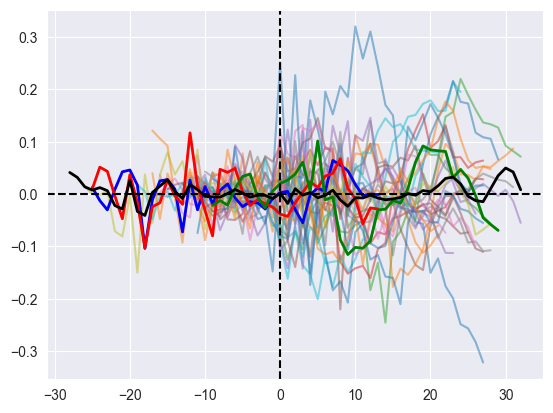

In [644]:
plt.plot(results_df_gap[treated_units], alpha=.5)
plt.plot(results_df_gap[['OH']], color='blue', linewidth=2 )
plt.plot(results_df_gap[['IL']], color='red' , linewidth=2)
plt.plot(results_df_gap[['NY']], color='green', linewidth=2 )

plt.plot(results_df_gap[treated_units].mean(axis=1), color='black', linewidth=2)
plt.axvline(0, color='black', linestyle='--')
plt.axhline(0, color='black', linestyle='--')

In [645]:
results_df_gap[treated_units].mean(axis=1).iloc[-33:]

lag
0     0.001760
1    -0.017809
2     0.010190
3    -0.002035
4     0.003123
5    -0.007171
6    -0.002245
7     0.007605
8    -0.011203
9    -0.023216
10   -0.006978
11   -0.007411
12   -0.002011
13   -0.007495
14   -0.010775
15   -0.009296
16   -0.006275
17    0.000928
18   -0.002152
19    0.006799
20    0.004491
21    0.015729
22    0.029926
23    0.032476
24    0.019524
25   -0.004016
26   -0.012428
27   -0.014501
28    0.010163
29    0.035228
30    0.049816
31    0.042212
32    0.008342
dtype: float64

In [493]:
#state_imbalance = ((test.T.values - np.dot(control, x0)) * np.abs(mask-1).T).mean(axis=1)
#state_imbalance[state_imbalance == 0] = np.nan   
#state_imbalance

In [494]:
#((test.T.values - np.dot(control, x0)) * np.abs(mask-1).T ).mean(axis=1)

In [495]:
#(test.T.values * np.abs(mask-1).T).mean(axis=1)  - (np.dot(control, x0)* np.abs(mask-1).T).mean(axis=1)

In [496]:
#(np.dot(control, x0)* np.abs(mask-1).T).mean(axis=1)

In [497]:
#np.dot(control, x0).mean(axis=1)

In [544]:
pre_t =  pd.DataFrame((test.T.values * np.abs(mask-1).T))  # Pre-treatment outcomes


post_t = pd.DataFrame((test.T.values * np.abs(mask).T)) # post-treatment outcomes

In [545]:
y.index

Index(['AK', 'CA', 'CT', 'DE', 'FL', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'MA',
       'MD', 'ME', 'MI', 'MN', 'MT', 'ND', 'NE', 'NH', 'NJ', 'NV', 'NY', 'OH',
       'OK', 'OR', 'PA', 'RI', 'SD', 'TN', 'VT', 'WA'],
      dtype='object', name='State')

In [546]:
#pre_t# [[0]][pre_t[[0]] > 0]


for t_unit in enumerate(y.index):
    # pre-fit 
    t_i = mask[t_unit[0]]
    y_i = y.loc[t_unit[1]].iloc[t_i==0].values 
    x_i = X.T.iloc[t_i==0] 
    
    pre_treatment_y_hat = x_i @ res.x.reshape(17,32)[:,t_unit[0]]
    post_treatment_y_hat = X.T.iloc[t_i==1] @ res.x.reshape(17,32)[:,t_unit[0]]
    
    pre_y = y_i
    post_y = y.loc[t_unit[1]].iloc[t_i==1].values
    
    #results[t_unit[1]]={}
    #results[t_unit[1]]['lagged_outcomes_est'] = np.concatenate([pre_treatment_y_hat, post_treatment_y_hat])
    #results[t_unit[1]]['lagged_outcomes_act'] = np.concatenate([pre_y, post_y])
    #results[t_unit[1]]['lagged_outcomes_te'] = results[t_unit[1]]['lagged_outcomes_act'] - results[t_unit[1]]['lagged_outcomes_est']
    results[t_unit[1]]['lagged_time_units'] = list(range(-len(pre_treatment_y_hat), 0, 1)) + list(range(0, len(post_treatment_y_hat), 1))
 


In [547]:
#pd.DataFrame((test.T.values * np.abs(mask).T))

In [548]:
def pooled_balance_objective(x): 
    
    x = x.reshape((17,32))
    #state_imbalance = ((test.T.values - np.dot(control, x)) * np.abs(mask-1).T).mean(axis=0)
    state_imbalance = (test.T.values * np.abs(mask-1).T).mean(axis=1)  - (np.dot(control, x)* np.abs(mask-1).T).mean(axis=1)
    
    state_imbalance[state_imbalance == 0] = np.nan   
    imbalance = np.nansum((state_imbalance**2))
    
    if penalty == "entropy":
        imbalance += penalty_strength * -np.sum(x * np.log(x))
    elif penalty == "l1":
        imbalance += penalty_strength * np.sum(np.abs(x))
    elif penalty == "l2":
        imbalance += penalty_strength * np.sum(np.square(x))
    else:
        raise NotImplemented(f"Unknown penalty {penalty}")
    return imbalance

In [549]:
control = wide_df.loc[control_units].T
test = wide_df.loc[treated_units] #* np.abs(mask-1))

In [550]:
(np.dot(control, res.x.reshape(17,32)) ).mean(axis=1)

array([-0.77456249, -0.70081946, -0.65534293, -0.6074769 , -0.5715743 ,
       -0.56013182, -0.46268024, -0.3940179 , -0.31065424, -0.31033209,
       -0.21953438, -0.216824  , -0.09679296, -0.11737254, -0.04227527,
       -0.08303173, -0.0464016 ,  0.01326327,  0.07055375,  0.08665972,
        0.16677398,  0.14423391,  0.1411482 ,  0.17942413,  0.212715  ,
        0.26394379,  0.29489002,  0.31122463,  0.31696047,  0.34974972,
        0.37428231,  0.3852402 ,  0.36992797,  0.36918174,  0.38187122,
        0.41460496,  0.42571032,  0.43561823,  0.46184732])

In [551]:
x0 = (np.ones((control.shape[1], test.shape[0])) /  control.shape[1] )#.flatten()

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    res = minimize(
        pooled_balance_objective,
        x0.flatten(),
        method="SLSQP",
        bounds=simplex_bounds,
        constraints={'type':'eq', 'fun': lambda x: np.sum(x.reshape(17,32), axis=0) - 1},
    )

In [552]:
res

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 0.022179794730262225
       x: [ 5.117e-02  4.755e-02 ...  7.566e-02  7.681e-02]
     nit: 8
     jac: [ 2.756e-03  2.888e-03 ...  2.760e-03  2.856e-03]
    nfev: 4360
    njev: 8

In [553]:
resultsp = {}


for t_unit in enumerate(y.index):
    # pre-fit 
    t_i = mask[t_unit[0]]
    y_i = y.loc[t_unit[1]].iloc[t_i==0].values 
    x_i = X.T.iloc[t_i==0] 
    
    pre_treatment_y_hat = x_i @ res.x.reshape(17,32)[:,t_unit[0]]
    post_treatment_y_hat = X.T.iloc[t_i==1] @ res.x.reshape(17,32)[:,t_unit[0]]
    
    pre_y = y_i
    post_y = y.loc[t_unit[1]].iloc[t_i==1].values
    
    resultsp[t_unit[1]]={}
    resultsp[t_unit[1]]['lagged_outcomes_est'] = np.concatenate([pre_treatment_y_hat, post_treatment_y_hat])
    resultsp[t_unit[1]]['lagged_outcomes_act'] = np.concatenate([pre_y, post_y])
    resultsp[t_unit[1]]['lagged_outcomes_te'] = resultsp[t_unit[1]]['lagged_outcomes_act'] - resultsp[t_unit[1]]['lagged_outcomes_est']
    resultsp[t_unit[1]]['lagged_time_units'] = list(range(-len(pre_treatment_y_hat), 0, 1)) + list(range(0, len(post_treatment_y_hat), 1))
 

results_dfp = np.empty((0,5))

for k in results:
    results_dfp = np.concatenate([results_dfp
                             , np.vstack([np.array(list([k]) * len(results[k]['lagged_time_units'])) 
                             , np.array(results[k]['lagged_time_units'])
                             , np.array(results[k]['lagged_outcomes_te'])
                             , np.array(results[k]['lagged_outcomes_act'])
                             , np.array(results[k]['lagged_outcomes_est'])]).T])
    
results_dfp = pd.DataFrame(results_dfp)
results_dfp.columns =['state','lag', 'pte', 'act', 'est']

results_dfp['pte'] = results_dfp['pte'].astype(float)
results_dfp.lag = results_dfp.lag.astype(int)


results_dfp_act = pd.pivot_table(results_dfp, index='state', columns='lag', values='act', aggfunc=np.max, fill_value=0).T
results_dfp_act.index = results_dfp_act.index.astype(int)
results_dfp_act = results_dfp_act.sort_index()

results_dfp_act[results_dfp_act == 0] = np.nan 

results_dfp_prd = pd.pivot_table(results_df, index='state', columns='lag', values='est', aggfunc=np.max, fill_value=0).T
results_dfp_prd.index = results_dfp_prd.index.astype(int)
results_dfp_prd = results_dfp_prd.sort_index()

results_dfp_prd[results_dfp_prd == 0] = np.nan 



results_dfp_gap = pd.pivot_table(results_dfp, index='state', columns='lag', values='pte', aggfunc=np.mean, fill_value=0).T
results_dfp_gap.index = results_dfp_gap.index.astype(int)
results_dfp_gap = results_dfp_gap.sort_index()

results_dfp_gap[results_dfp_gap == 0] = np.nan 

/var/folders/cd/dfrqgp4s4ll55cwb7rtgccbw0000gq/T/ipykernel_48731/3610729909.py:40: FutureWarning: The provided callable <function max at 0x113456dc0> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  results_dfp_act = pd.pivot_table(results_dfp, index='state', columns='lag', values='act', aggfunc=np.max, fill_value=0).T
/var/folders/cd/dfrqgp4s4ll55cwb7rtgccbw0000gq/T/ipykernel_48731/3610729909.py:46: FutureWarning: The provided callable <function max at 0x113456dc0> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  results_dfp_prd = pd.pivot_table(results_df, index='state', columns='lag', values='est', aggfunc=np.max, fill_value=0).T
/var/folders/cd/dfrqgp4s4ll55cwb7rtgccbw0000gq/T/ipykernel_48731/3610729909.py:54: FutureWarning: The provi

In [554]:
res

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 0.022179794730262225
       x: [ 5.117e-02  4.755e-02 ...  7.566e-02  7.681e-02]
     nit: 8
     jac: [ 2.756e-03  2.888e-03 ...  2.760e-03  2.856e-03]
    nfev: 4360
    njev: 8

In [555]:
results_dfp_act = results_dfp_act.apply(pd.to_numeric, errors='coerce')
results_dfp_prd = results_dfp_prd.apply(pd.to_numeric, errors='coerce')


Text(0.5, 1.0, '')

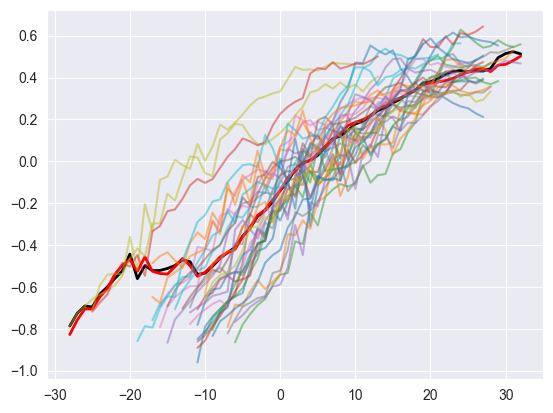

In [556]:
plt.plot(results_dfp_act.mean(axis=1) , color='black', linewidth=2)  
plt.plot(results_dfp_prd.mean(axis=1) , color='red', linewidth=2)  


plt.plot(results_dfp_act,  alpha=.5)
#plt.plot(results_df_gap.mean(axis=1))
plt.title("")

Text(0.5, 1.0, '')

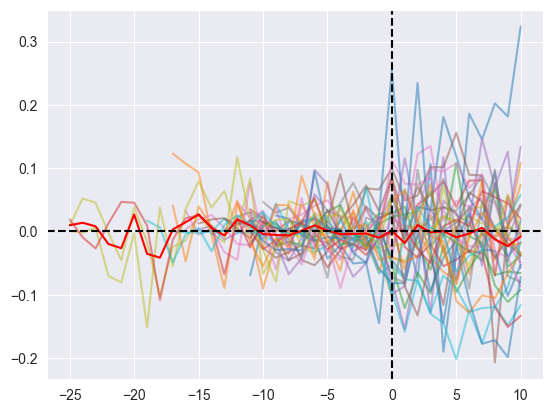

In [557]:
plt.plot(results_dfp_gap.loc[-25:10],  alpha=.5)
plt.plot(results_dfp_gap.loc[-25:10].mean(axis=1),  alpha=1, color='red')
#plt.plot(results_dfp_act.mean(axis=1) - results_dfp_prd.mean(axis=1) ,  alpha=1, color='red')

plt.axhline(0, color='black', linestyle='--')
plt.axvline(0, color='black', linestyle='--')
plt.title("")

In [559]:
results_dfp_gap.loc[-25:10].mean(axis=1)[-11:]

lag
0     0.001119
1    -0.018423
2     0.010243
3    -0.001511
4     0.000528
5    -0.009377
6    -0.003388
7     0.005679
8    -0.012483
9    -0.023256
10   -0.007796
dtype: float64

In [560]:
results_dfp_gap.loc[-25:10].std(axis=1)[-11:]

lag
0     0.078372
1     0.066618
2     0.068436
3     0.071053
4     0.080399
5     0.074185
6     0.070823
7     0.078439
8     0.086455
9     0.076100
10    0.085272
dtype: float64

Text(0.5, 1.0, '')

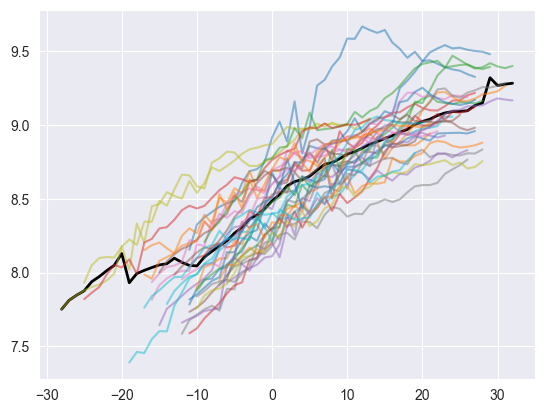

In [430]:
plt.plot(results_df_act.mean(axis=1) , color='black', linewidth=2)  
plt.plot(results_df_act,  alpha=.5)
plt.title("")

In [440]:
predictions = (np.dot(control, res.x.reshape((17,32))) ).mean(axis=1)

In [441]:
predictions

array([7.83850414, 7.92428869, 7.9557029 , 8.00404681, 8.04184133,
       8.05027495, 8.11224355, 8.21393662, 8.22869928, 8.243     ,
       8.30348391, 8.34524089, 8.41845718, 8.4450762 , 8.46189874,
       8.45879878, 8.49631081, 8.54504317, 8.58212049, 8.63686177,
       8.68848637, 8.69868707, 8.70502186, 8.7421525 , 8.77649686,
       8.80501566, 8.83500471, 8.86222358, 8.84563875, 8.87084258,
       8.8712472 , 8.8683029 , 8.84770304, 8.83691164, 8.83029619,
       8.8583748 , 8.86076564, 8.85848305, 8.88963055])

In [442]:
results_df_act.mean(axis=1)

lag
-28    7.751139
-27    7.812168
-26    7.846658
-25    7.876295
-24    7.937830
         ...   
 28    9.150484
 29    9.321110
 30    9.268555
 31    9.277418
 32    9.283812
Length: 61, dtype: float64

In [414]:
#pd.DataFrame((test.T.values * np.abs(mask-1).T)).plot(legend=False)
#pd.DataFrame((np.dot(control, res.x.reshape((17,32)))* np.abs(mask-1).T)).plot(legend=False)

In [415]:
#results_df_act.mean(axis=1) - 
results_df_prd.shape

(61, 32)

In [416]:
results_df_act = results_df_act.apply(pd.to_numeric, errors='coerce')
results_df_prd = results_df_prd.apply(pd.to_numeric, errors='coerce')

pool_df = pd.DataFrame(zip(list(range(-28,11)), predictions)) 

In [417]:
# plt.plot(results_df_act.mean(axis=1) - results_df_prd.mean(axis=1))

In [418]:
pool_df.columns = ['lag', 'pte']

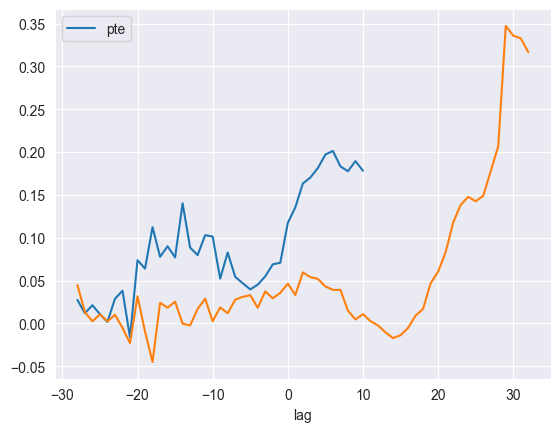

In [420]:
pool_df.plot(x='lag', y='pte')
plt.plot(results_df_act.mean(axis=1) - results_df_prd.mean(axis=1))

In [404]:
pool_df.loc[:28]

,lag,pte
0,-28,0.027370
1,-27,0.011821
2,-26,0.021169
3,-25,0.010623
4,-24,0.001609
5,-23,0.028691
6,-22,0.030064
7,-21,-0.022063
8,-20,0.050907
9,-19,0.015750


In [396]:
#results_df_act.mean(axis=1, skipna=True)
#results_df_act.isna().sum()

results_df_act = results_df_act.apply(pd.to_numeric, errors='coerce')
results_df_prd = results_df_prd.apply(pd.to_numeric, errors='coerce')


In [316]:
#row_wise_average = results_df_act.mean(axis=1, skipna=True)


In [317]:
#plt.plot(row_wise_average)

In [318]:
#predictions = (test.T.values * np.abs(mask-1).T).mean(axis=1)  - (np.dot(control, res.x.reshape((17,32)))* np.abs(mask-1).T).mean(axis=1)

In [327]:
est = (np.dot(control, res.x.reshape((17,32)))* np.abs(mask-1).T).mean(axis=1) 

In [332]:
(test.T.values * np.abs(mask-1).T).mean(axis=1) 

array([7.86587418, 7.93611014, 7.97687168, 8.01466991, 8.04344996,
       8.07896587, 7.63747955, 7.16919543, 7.25379903, 6.71759634,
       5.76414422, 4.17368433, 3.43646512, 3.17123975, 2.934892  ,
       2.38566475, 1.85273691, 1.07024375, 1.06826572, 0.81323278,
       0.817933  , 0.81500731, 0.81435556, 0.81597812, 0.82066884,
       0.27611269, 0.27646538, 0.27695038, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        ])

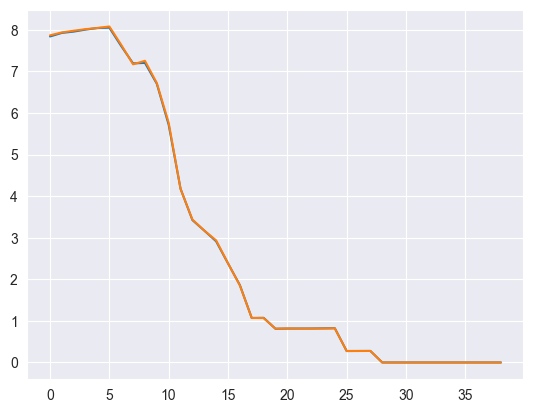

In [333]:
plt.plot(est)
plt.plot((test.T.values * np.abs(mask-1).T).mean(axis=1) )

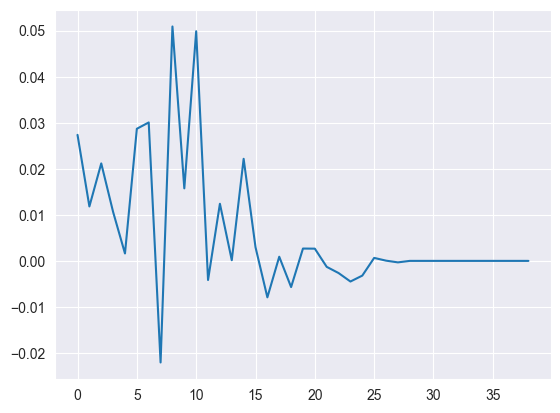

In [335]:
plt.plot((test.T.values * np.abs(mask-1).T).mean(axis=1)  - est)

In [185]:
results = {}


for t_unit in enumerate(y.index):
    # pre-fit 
    t_i = mask[t_unit[0]]
    y_i = y.loc[t_unit[1]].iloc[t_i==0].values 
    x_i = X.T.iloc[t_i==0] 
    
    pre_treatment_y_hat = x_i @ res.x.reshape(17,32)[:,t_unit[0]]
    post_treatment_y_hat = X.T.iloc[t_i==1] @ res.x.reshape(17,32)[:,t_unit[0]]
    
    pre_y = y_i
    post_y = y.loc[t_unit[1]].iloc[t_i==1].values
    
    results[t_unit[1]]={}
    results[t_unit[1]]['lagged_outcomes_est'] = np.concatenate([pre_treatment_y_hat, post_treatment_y_hat])
    results[t_unit[1]]['lagged_outcomes_act'] = np.concatenate([pre_y, post_y])
    results[t_unit[1]]['lagged_outcomes_te'] = results[t_unit[1]]['lagged_outcomes_act'] - results[t_unit[1]]['lagged_outcomes_est']
    results[t_unit[1]]['lagged_time_units'] = list(range(-len(pre_treatment_y_hat), 0, 1)) + list(range(0, len(post_treatment_y_hat), 1))
 

results_df = np.empty((0,5))

for k in results:
    results_df = np.concatenate([results_df
                             , np.vstack([np.array(list([k]) * len(results[k]['lagged_time_units'])) 
                             , np.array(results[k]['lagged_time_units'])
                             , np.array(results[k]['lagged_outcomes_te'])
                             , np.array(results[k]['lagged_outcomes_act'])
                             , np.array(results[k]['lagged_outcomes_est'])]).T])
    
results_df = pd.DataFrame(results_df)
results_df.columns =['state','lag', 'pte', 'act', 'est']

results_df['pte'] = results_df['pte'].astype(float)
results_df.lag = results_df.lag.astype(int)

results_df_gap = pd.pivot_table(results_df, index='state', columns='lag', values='pte', aggfunc=np.mean, fill_value=0).T
results_df_gap.index = results_df_gap.index.astype(int)
results_df_gap = results_df_gap.sort_index()

results_df_gap[results_df_gap == 0] = np.nan 

/var/folders/cd/dfrqgp4s4ll55cwb7rtgccbw0000gq/T/ipykernel_48731/1050486597.py:39: FutureWarning: The provided callable <function mean at 0x11345b700> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  results_df_gap = pd.pivot_table(results_df, index='state', columns='lag', values='pte', aggfunc=np.mean, fill_value=0).T


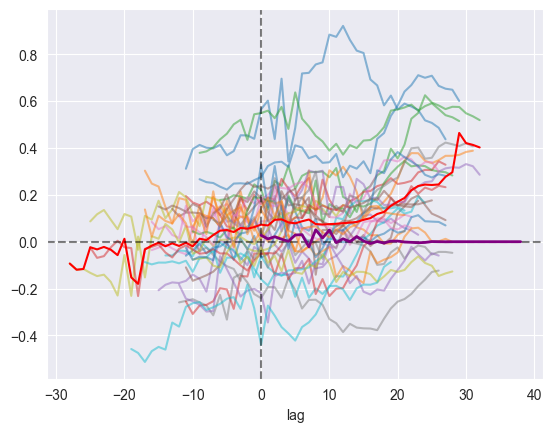

In [171]:
results_df_gap.plot(legend=False, alpha=.5)
results_df_gap.mean(axis=1).plot(legend=False, color='red')
plt.axhline(0, color='black', linestyle='--', alpha=.5)
plt.axvline(0, color='black', linestyle='--', alpha=.5)

plt.plot(predictions, color='purple' , linewidth=2)

/var/folders/cd/dfrqgp4s4ll55cwb7rtgccbw0000gq/T/ipykernel_48731/2082410379.py:1: FutureWarning: The provided callable <function mean at 0x11345b700> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df1 = pd.pivot_table(results_df, index='state', columns='lag', values='pte', aggfunc=np.mean, fill_value=0).T


<Axes: xlabel='lag'>

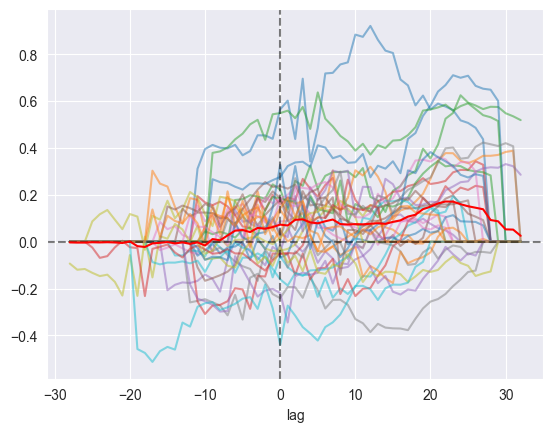

In [181]:
df1 = pd.pivot_table(results_df, index='state', columns='lag', values='pte', aggfunc=np.mean, fill_value=0).T
df1.plot(legend=False, alpha=.5)
plt.axhline(0, color='black', linestyle='--', alpha=.5)
plt.axvline(0, color='black', linestyle='--', alpha=.5)
df1.mean(axis=1).plot(legend=False, color='red')

In [186]:
#(np.dot(control, res.x.reshape((17,32)))* np.abs(mask-1).T).mean(axis=1)
#(test.T.values * np.abs(mask-1).T).mean(axis=1) 

In [ ]:
predictions = (test.T.values * np.abs(mask-1).T).mean(axis=1)  - (np.dot(control, res.x.reshape((17,32)))* np.abs(mask-1).T).mean(axis=1)

In [189]:
for t_unit in enumerate(y.index):
    
    # pre-fit 
    t_i = mask[t_unit[0]]
    y_i = y.loc[t_unit[1]].iloc[t_i==0].values 
    x_i = X.T.iloc[t_i==0] 
    
    pre_treatment_y_hat = x_i @ res.x.reshape(17,32)[:,t_unit[0]]
    post_treatment_y_hat = X.T.iloc[t_i==1] @ res.x.reshape(17,32)[:,t_unit[0]]


In [198]:
X.T @ res.x.reshape(17,32)

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
year,,,,,,,,,,,,,,,,,,,,,
1959,7.843255,7.849075,7.798851,7.843255,7.849878,7.843255,7.850967,7.842648,7.844321,7.845644,...,7.827553,7.844321,7.842648,7.849878,7.842648,7.821441,7.831999,7.848020,7.843255,7.849075
1960,7.930136,7.937128,7.879857,7.930136,7.938311,7.930136,7.939688,7.929353,7.931689,7.933033,...,7.909574,7.931689,7.929353,7.938311,7.929353,7.902506,7.915109,7.935817,7.930136,7.937129
1961,7.961186,7.968489,7.913674,7.961186,7.969566,7.961186,7.970874,7.960417,7.963030,7.964096,...,7.941014,7.963030,7.960417,7.969566,7.960417,7.934331,7.946402,7.967117,7.961186,7.968489
1962,8.009657,8.016348,7.961776,8.009657,8.017487,8.009657,8.018768,8.008929,8.011295,8.012400,...,7.989820,8.011295,8.008929,8.017487,8.008929,7.983290,7.994991,8.015050,8.009657,8.016348
1963,8.047374,8.052784,8.000840,8.047374,8.053909,8.047374,8.055126,8.046684,8.048565,8.049745,...,8.029012,8.048565,8.046684,8.053909,8.046684,8.023038,8.033945,8.051717,8.047374,8.052784
1964,8.056477,8.062775,8.006064,8.056477,8.064060,8.056477,8.065418,8.055662,8.057789,8.059184,...,8.035137,8.057789,8.055662,8.064060,8.055662,8.028704,8.040738,8.061484,8.056477,8.062775
1965,8.117378,8.120351,8.077254,8.117378,8.121311,8.117378,8.122217,8.116775,8.117075,8.118949,...,8.102044,8.117075,8.116775,8.121311,8.116775,8.097634,8.106700,8.119550,8.117378,8.120351
1966,8.220013,8.227509,8.171144,8.220013,8.228538,8.220013,8.230001,8.218896,8.222535,8.222972,...,8.196471,8.222535,8.218896,8.228538,8.218896,8.191711,8.202938,8.226056,8.220013,8.227509
1967,8.232700,8.238071,8.199915,8.232700,8.238895,8.232700,8.239890,8.232040,8.234284,8.234815,...,8.217132,8.234284,8.232040,8.238895,8.232040,8.213007,8.221216,8.237063,8.232700,8.238071


In [191]:
post_treatment_y_hat

year
1976    8.559223
1977    8.596898
1978    8.651862
1979    8.702746
1980    8.714582
1981    8.723463
1982    8.761420
1983    8.798935
1984    8.825400
1985    8.855466
1986    8.882777
1987    8.863866
1988    8.888654
1989    8.887898
1990    8.883366
1991    8.861629
1992    8.850954
1993    8.842273
1994    8.869676
1995    8.870589
1996    8.867474
1997    8.898662
dtype: float64